## MNIST dataset(숫자 이미지)으로 숫자 분류 모델
숫자 손글씨 이미지에 대한 데이터와 라벨이 포함되어 있으며 60000개의 트레이닝 데이터와 10000개의 테스트 데이터로 구성됨

In [1]:
import tensorflow as tf
import sys
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import keras

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0 

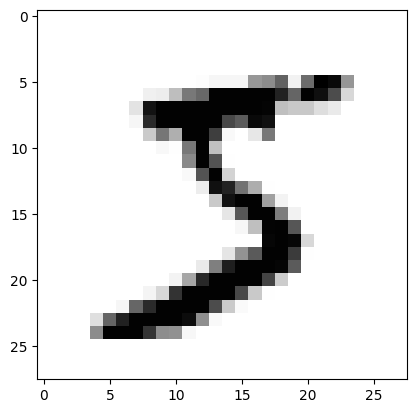

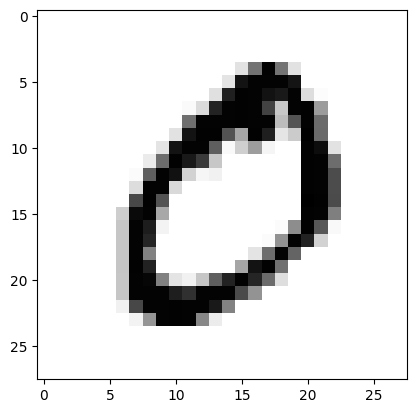

In [2]:
(x_train, y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()
# mnist 데이터를 불러옴 이 데이터는 훈련용 60,000개와 테스트용 10,000개로 나뉘어 있음
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
# 각각의 형태를 출력한다.

print(x_train[0])   # 0번째 feature
print(y_train[0])   

# for i in x_train[0]:
#     for j in i:
#         sys.stdout.write('%s  '%j)
#     sys.stdout.write('\n')

plt.imshow(x_train[0], cmap='Greys')
plt.show()
plt.imshow(x_train[1], cmap='Greys')
plt.show()

In [3]:
from types import new_class


x_train = x_train.reshape(60000, 784).astype('float32')     # 28 by 28 => 784 열 변경
x_test = x_test.reshape(10000, 784).astype('float32')
# print(x_train[0])

x_train /= 255.0    # 정규화: 필수는 아니다. 하지만 해 주면 모델 성능 향상
x_test /= 255.0
# print(x_train[0])

# label: Onehot incoding:  출력층 활성화 함수를 softmax를 사용하기 때문에
print(set(y_train))
print(y_train[0])
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_train[0])

# validation data
x_val = x_train[50000:60000]
y_val = y_train[50000:60000]
x_train = x_train[0:50000]
y_train = y_train[0:50000]
print(x_val.shape, x_train.shape)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
(10000, 784) (50000, 784)


### model

In [4]:
from tabnanny import verbose
from sklearn import metrics
from tensorflow.keras.layers import Activation, Dropout, BatchNormalization
model= Sequential()
model.add(Input(shape=(784,)))  # Flatten() 차원을 떨궈줌
# model.add(Dense(units=64))
# model.add(Activation('relu'))
# model.add(Dropout(rate=0.2))
# model.add(Dense(units=32))
# model.add(Activation('relu'))
# model.add(Dropout(rate=0.2))
# model.add(Dense(units=10))
# model.add(Activation('softmax'))

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate=0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(rate=0.2))
model.add(Dense(units=10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

history = model.fit(x_train, y_train, epochs=10, batch_size=128,validation_data=(x_val, y_val), verbose=2)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/10
391/391 - 3s - loss: 0.6605 - accura

loss : [0.6605070233345032, 0.3279094994068146, 0.25988003611564636, 0.22228458523750305, 0.1990620642900467, 0.18048390746116638, 0.16761498153209686, 0.15669678151607513, 0.14541421830654144, 0.13830716907978058]
val_loss : [0.22905224561691284, 0.1729201227426529, 0.14504815638065338, 0.13318359851837158, 0.1207776889204979, 0.11255016922950745, 0.10744285583496094, 0.10664614289999008, 0.10424868017435074, 0.10210391134023666]
accuracy : [0.7973200082778931, 0.9044399857521057, 0.9229400157928467, 0.9348400235176086, 0.9417999982833862, 0.9473999738693237, 0.9497399926185608, 0.9534800052642822, 0.9562000036239624, 0.9589999914169312]
val_accuracy : [0.9358000159263611, 0.9498000144958496, 0.9603999853134155, 0.9650999903678894, 0.9661999940872192, 0.9686999917030334, 0.9714999794960022, 0.9704999923706055, 0.9718000292778015, 0.9714000225067139]


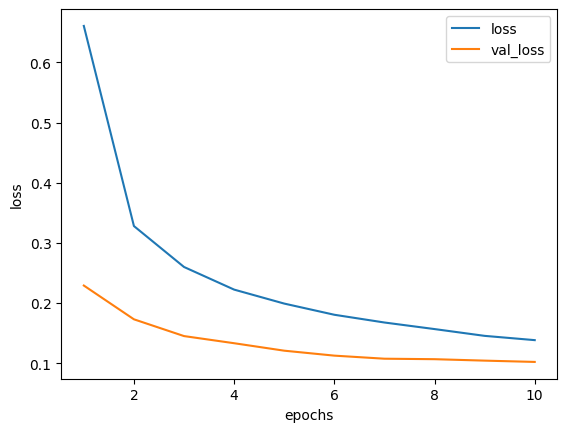

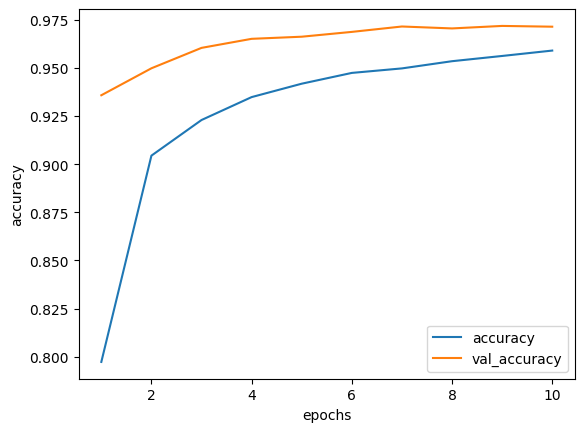

In [5]:
print(f"loss : {history.history['loss']}")
print(f"val_loss : {history.history['val_loss']}")
print(f"accuracy : {history.history['accuracy']}")
print(f"val_accuracy : {history.history['val_accuracy']}")

epochs = range(1, len(history.history['loss'])+ 1)
plt.plot(epochs, history.history['loss'], label='loss')
plt.plot(epochs, history.history['val_loss'], label='val_loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(loc='best')
plt.show()

plt.clf()
plt.plot(epochs, history.history['accuracy'], label='accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(loc='best')
plt.show()

loss:  0.10239483416080475
acc:  0.9703999757766724


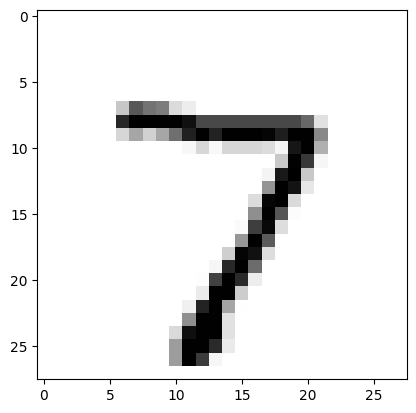

In [6]:
score = model.evaluate(x_test, y_test, batch_size=128, verbose=0)
print('loss: ', score[0])
print('acc: ', score[1])

model.save('tf27model.keras')

# del model

mymodel = tf.keras.models.load_model('tf27model.keras')

# print(x_test[:1], x_test[:1].shape)
plt.imshow(x_test[:1].reshape(28, 28), cmap='Greys')
plt.show()